In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#importing 100k random rows of Motor Vehicle Collisions from NYC Open Data
import requests
import json
import pandas as pd
import numpy as np

# URL for the Motor Vehicle Collisions - Crashes dataset CSV download
csv_url = "https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.csv?accessType=DOWNLOAD"
# API endpoint to get the total row count for the dataset
api_count_url = "https://data.cityofnewyork.us/resource/h9gi-nx95.json?$select=count(*)"

# 1. Get total number of rows from the API for random sampling
print("Fetching total number of rows from the NYC OpenData API...")
total_rows = None
try:
    response = requests.get(api_count_url)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()
    total_rows = int(data[0]['count'])
    print(f"Total rows in the dataset: {total_rows}")
except requests.exceptions.RequestException as e:
    print(f"Error fetching row count from API: {e}")
    print("Could not determine total row count for random sampling. Proceeding with fallback.")
except (json.JSONDecodeError, KeyError) as e:
    print(f"Error parsing row count from API response: {e}")
    print("Could not determine total row count for random sampling. Proceeding with fallback.")

df = None # Initialize DataFrame

if total_rows is not None:
    sample_size = 100000
    if sample_size > total_rows:
        print(f"Requested sample size ({sample_size}) is greater than total rows ({total_rows}). Importing all {total_rows} rows.")
        sample_size = total_rows

    # Generate `sample_size` unique random 1-indexed data row numbers to keep.
    # Line 0 is the header, data lines are 1 to total_rows.
    rows_to_keep_data_indices = set(np.random.choice(range(1, total_rows + 1), sample_size, replace=False))

    # Define a skiprows callable function for pandas.read_csv
    # It takes a 0-indexed line number. Returns True to skip, False to keep.
    def skip_random_rows(line_num):
        if line_num == 0: # Always keep the header row
            return False
        # For data rows, skip if its 1-indexed row number is NOT in our set of rows to keep
        return (line_num not in rows_to_keep_data_indices)

    print(f"Importing {sample_size} random rows from the CSV URL...")
    try:
        df = pd.read_csv(csv_url, skiprows=skip_random_rows)
        print("Successfully imported a random subset of data.")
    except Exception as e:
        print(f"Error importing CSV with random skiprows: {e}")
        print("This method can be sensitive to network conditions or file structure. Falling back to importing the first 100,000 rows.")

if df is None: # If the random import failed or total_rows was not determined
    print("Attempting to import the first 100,000 rows (not random) as a fallback.")
    try:
        df = pd.read_csv(csv_url, nrows=100000)
        print("Successfully imported the first 100,000 rows.")
    except Exception as e_fallback:
        print(f"Fallback import also failed: {e_fallback}")
        print("Please check the URL or consider downloading the CSV locally if issues persist.")

if df is not None:
    print(f"Shape of the imported DataFrame: {df.shape}")
    print("First 5 rows of the DataFrame:")
    print(df.head())

Fetching total number of rows from the NYC OpenData API...
Total rows in the dataset: 2262089
Importing 100000 random rows from the CSV URL...
Successfully imported a random subset of data.
Shape of the imported DataFrame: (100000, 29)
First 5 rows of the DataFrame:
   CRASH DATE CRASH TIME    BOROUGH ZIP CODE   LATITUDE  LONGITUDE  \
0  12/11/2021       4:45  MANHATTAN  10001.0  40.748917 -73.993546   
1  12/14/2021      20:13   BROOKLYN  11215.0  40.665760 -73.984500   
2  03/26/2022      21:00   BROOKLYN  11219.0  40.629475 -74.004166   
3  03/26/2022      11:20        NaN      NaN  40.624763 -73.965180   
4  09/09/2021       8:15   BROOKLYN  11238.0  40.680664 -73.970280   

                  LOCATION       ON STREET NAME CROSS STREET NAME  \
0  (40.748917, -73.993546)                  NaN               NaN   
1     (40.66576, -73.9845)                  NaN               NaN   
2  (40.629475, -74.004166)                  NaN               NaN   
3   (40.624763, -73.96518)  CONEY IS

/tmp/ipykernel_1100/69397354.py:49: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_url, skiprows=skip_random_rows)


In [3]:
print(df.tail())

       CRASH DATE CRASH TIME   BOROUGH ZIP CODE   LATITUDE  LONGITUDE  \
99995  05/12/2026       8:49     BRONX  10455.0  40.817930 -73.905290   
99996  05/12/2026       8:05  BROOKLYN  11207.0  40.672195 -73.902660   
99997  05/12/2026      18:34    QUEENS  11366.0  40.727802 -73.805150   
99998  05/12/2026       9:20    QUEENS  11373.0  40.743942 -73.872420   
99999  05/10/2026      22:29  BROOKLYN  11217.0  40.688072 -73.979385   

                      LOCATION   ON STREET NAME CROSS STREET NAME  \
99995    (40.81793, -73.90529)  WESTCHESTER AVE          E 156 ST   
99996   (40.672195, -73.90266)     GLENMORE AVE  VAN SINDEREN AVE   
99997   (40.727802, -73.80515)           73 AVE            164 ST   
99998   (40.743942, -73.87242)           43 AVE         FORLEY ST   
99999  (40.688072, -73.979385)              NaN               NaN   

             OFF STREET NAME  ...  CONTRIBUTING FACTOR VEHICLE 2  \
99995                    NaN  ...                    Unspecified   
99996     

In [4]:
#to display columns
df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')

In [23]:
df.describe()

,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,COLLISION_ID
count,89416.000000,89416.000000,100000.000000,99909.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,40.587786,-73.680228,0.334120,0.001591,0.059730,0.000750,0.03040,0.000170,0.239260,0.000630,3.288696e+06
std,2.348383,4.368767,0.714009,0.040853,0.250406,0.027376,0.17446,0.013037,0.673082,0.026639,1.514193e+06
min,0.000000,-201.237060,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,4.200000e+01
25%,40.667277,-73.974495,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,3.198892e+06
50%,40.719760,-73.927080,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,3.763970e+06
75%,40.768919,-73.866103,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,4.325823e+06
max,41.126150,0.000000,19.000000,2.000000,6.000000,1.000000,2.00000,1.000000,15.000000,2.000000,4.898821e+06


In [5]:
#cleaning unneeded columns
columns_to_drop = [
    'CRASH TIME',
    'ZIP CODE',
    'LATITUDE',
    'LONGITUDE',
    'LOCATION',
    'ON STREET NAME',
    'CROSS STREET NAME',
    'OFF STREET NAME',
    'CONTRIBUTING FACTOR VEHICLE 1',
    'CONTRIBUTING FACTOR VEHICLE 2',
    'CONTRIBUTING FACTOR VEHICLE 3',
    'CONTRIBUTING FACTOR VEHICLE 4',
    'CONTRIBUTING FACTOR VEHICLE 5'
]

df_cleaned = df.drop(columns=columns_to_drop)

print(f"Shape of the DataFrame after dropping columns: {df_cleaned.shape}")
print("First 5 rows of the cleaned DataFrame:")
print(df_cleaned.head())

Shape of the DataFrame after dropping columns: (100000, 16)
First 5 rows of the cleaned DataFrame:
   CRASH DATE    BOROUGH  NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  \
0  12/11/2021  MANHATTAN                          0                       0.0   
1  12/14/2021   BROOKLYN                          0                       0.0   
2  03/26/2022   BROOKLYN                          0                       0.0   
3  03/26/2022        NaN                          1                       0.0   
4  09/09/2021   BROOKLYN                          0                       0.0   

   NUMBER OF PEDESTRIANS INJURED  NUMBER OF PEDESTRIANS KILLED  \
0                              0                             0   
1                              0                             0   
2                              0                             0   
3                              0                             0   
4                              0                             0   

   NUMBER OF CYCL

In [6]:
#creating subset for each borough
df_cleaned_no_nan_borough = df_cleaned.dropna(subset=['BOROUGH'])

print(f"Shape of the DataFrame after dropping rows with NaN values in 'BOROUGH': {df_cleaned_no_nan_borough.shape}")
print("First 5 rows of the DataFrame after dropping NaN values in 'BOROUGH':")
print(df_cleaned_no_nan_borough.head())

Shape of the DataFrame after dropping rows with NaN values in 'BOROUGH': (69514, 16)
First 5 rows of the DataFrame after dropping NaN values in 'BOROUGH':
   CRASH DATE    BOROUGH  NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  \
0  12/11/2021  MANHATTAN                          0                       0.0   
1  12/14/2021   BROOKLYN                          0                       0.0   
2  03/26/2022   BROOKLYN                          0                       0.0   
4  09/09/2021   BROOKLYN                          0                       0.0   
5  12/09/2021   BROOKLYN                          0                       0.0   

   NUMBER OF PEDESTRIANS INJURED  NUMBER OF PEDESTRIANS KILLED  \
0                              0                             0   
1                              0                             0   
2                              0                             0   
4                              0                             0   
5                           

In [7]:
#sum of traffic incidents
df_cleaned_no_nan_borough.loc[:, 'Total Injuries'] = \
    df_cleaned_no_nan_borough['NUMBER OF PERSONS INJURED'] + \
    df_cleaned_no_nan_borough['NUMBER OF PERSONS KILLED'] + \
    df_cleaned_no_nan_borough['NUMBER OF PEDESTRIANS INJURED'] + \
    df_cleaned_no_nan_borough['NUMBER OF PEDESTRIANS KILLED'] + \
    df_cleaned_no_nan_borough['NUMBER OF CYCLIST INJURED'] + \
    df_cleaned_no_nan_borough['NUMBER OF CYCLIST KILLED'] + \
    df_cleaned_no_nan_borough['NUMBER OF MOTORIST INJURED'] + \
    df_cleaned_no_nan_borough['NUMBER OF MOTORIST KILLED']

print("First 5 rows of the DataFrame with the new 'Total Injuries' column:")
print(df_cleaned_no_nan_borough.head())

First 5 rows of the DataFrame with the new 'Total Injuries' column:
   CRASH DATE    BOROUGH  NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  \
0  12/11/2021  MANHATTAN                          0                       0.0   
1  12/14/2021   BROOKLYN                          0                       0.0   
2  03/26/2022   BROOKLYN                          0                       0.0   
4  09/09/2021   BROOKLYN                          0                       0.0   
5  12/09/2021   BROOKLYN                          0                       0.0   

   NUMBER OF PEDESTRIANS INJURED  NUMBER OF PEDESTRIANS KILLED  \
0                              0                             0   
1                              0                             0   
2                              0                             0   
4                              0                             0   
5                              0                             0   

   NUMBER OF CYCLIST INJURED  NUMBER OF CYCLIST 

/tmp/ipykernel_1100/792958168.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned_no_nan_borough.loc[:, 'Total Injuries'] = \


In [8]:
#removing nolonger needed data
columns_to_remove_details = [
    'NUMBER OF PERSONS INJURED',
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF CYCLIST INJURED',
    'NUMBER OF MOTORIST INJURED'
    ]

df_final = df_cleaned_no_nan_borough.drop(columns=columns_to_remove_details)

print(f"Shape of the DataFrame after removing detailed injury/fatality columns: {df_final.shape}")
print("First 5 rows of the final DataFrame:")
print(df_final.head())

Shape of the DataFrame after removing detailed injury/fatality columns: (69514, 13)
First 5 rows of the final DataFrame:
   CRASH DATE    BOROUGH  NUMBER OF PERSONS KILLED  \
0  12/11/2021  MANHATTAN                       0.0   
1  12/14/2021   BROOKLYN                       0.0   
2  03/26/2022   BROOKLYN                       0.0   
4  09/09/2021   BROOKLYN                       0.0   
5  12/09/2021   BROOKLYN                       0.0   

   NUMBER OF PEDESTRIANS KILLED  NUMBER OF CYCLIST KILLED  \
0                             0                         0   
1                             0                         0   
2                             0                         0   
4                             0                         0   
5                             0                         0   

   NUMBER OF MOTORIST KILLED  COLLISION_ID  \
0                          0       4486905   
1                          0       4486605   
2                          0       4513861   
4  

In [9]:
print(df_final.tail())

       CRASH DATE   BOROUGH  NUMBER OF PERSONS KILLED  \
99995  05/12/2026     BRONX                       NaN   
99996  05/12/2026  BROOKLYN                       NaN   
99997  05/12/2026    QUEENS                       NaN   
99998  05/12/2026    QUEENS                       NaN   
99999  05/10/2026  BROOKLYN                       NaN   

       NUMBER OF PEDESTRIANS KILLED  NUMBER OF CYCLIST KILLED  \
99995                             0                         0   
99996                             0                         0   
99997                             0                         0   
99998                             0                         0   
99999                             0                         0   

       NUMBER OF MOTORIST KILLED  COLLISION_ID  \
99995                          0       4898489   
99996                          0       4898583   
99997                          0       4898366   
99998                          0       4898460   
99999           

In [10]:
#number of collisions in each borough
queens_collisions = df_final[df_final['BOROUGH'] == 'QUEENS']
total_queens_collisions = queens_collisions['Total Injuries'].sum()

print(f"Total number of collisions in Queens: {int(total_queens_collisions)}")

Total number of collisions in Queens: 12273


In [11]:
manhattan_collisions = df_final[df_final['BOROUGH'] == 'MANHATTAN']
total_manhattan_collisions = manhattan_collisions['Total Injuries'].sum()

print(f"Total number of collisions in Manhattan: {int(total_manhattan_collisions)}")

Total number of collisions in Manhattan: 6919


In [12]:
brooklyn_collisions = df_final[df_final['BOROUGH'] == 'BROOKLYN']
total_brooklyn_collisions = brooklyn_collisions['Total Injuries'].sum()

print(f"Total number of collisions in Brooklyn: {int(total_brooklyn_collisions)}")

Total number of collisions in Brooklyn: 16075


In [13]:
bronx_collisions = df_final[df_final['BOROUGH'] == 'BRONX']
total_bronx_collisions = bronx_collisions['Total Injuries'].sum()

print(f"Total number of collisions in Bronx: {int(total_bronx_collisions)}")

Total number of collisions in Bronx: 6919


In [14]:
staten_island_collisions = df_final[df_final['BOROUGH'] == 'STATEN ISLAND']
total_staten_island_collisions = staten_island_collisions['Total Injuries'].sum()

print(f"Total number of collisions in Staten Island: {int(total_staten_island_collisions)}")

Total number of collisions in Staten Island: 1863


/tmp/ipykernel_1100/3164061393.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Borough', y='Total Collisions', data=collisions_df, palette='viridis')


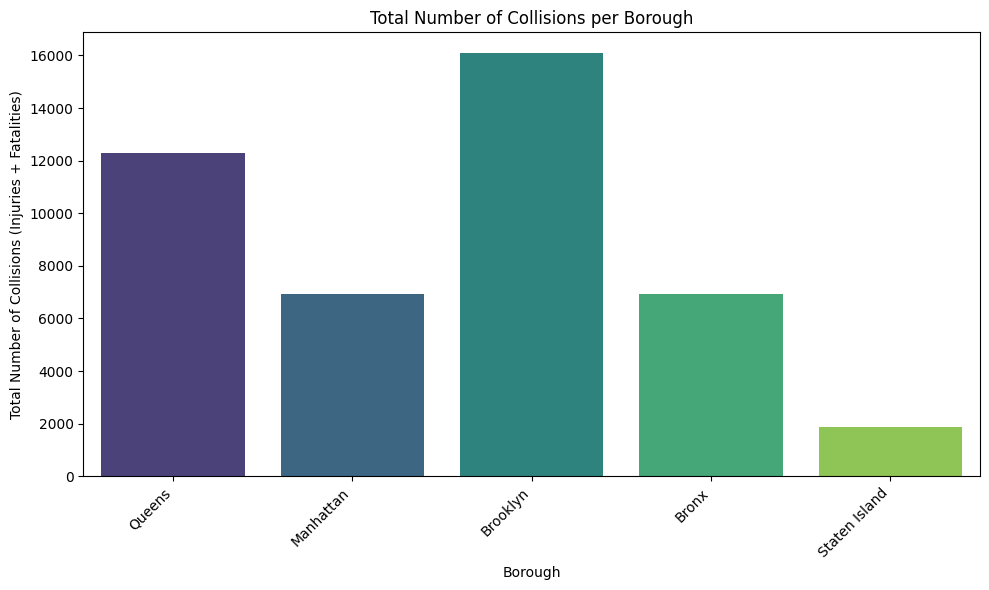

In [15]:
#creating borough comparison bar graph
collision_data = {
    'Borough': ['Queens', 'Manhattan', 'Brooklyn', 'Bronx', 'Staten Island'],
    'Total Collisions': [
        total_queens_collisions,
        total_manhattan_collisions,
        total_brooklyn_collisions,
        total_bronx_collisions,
        total_staten_island_collisions
    ]
}

collisions_df = pd.DataFrame(collision_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Borough', y='Total Collisions', data=collisions_df, palette='viridis')
plt.title('Total Number of Collisions per Borough')
plt.xlabel('Borough')
plt.ylabel('Total Number of Collisions (Injuries + Fatalities)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Brooklyn has the highest number of collisions between the boroughs. Staten Islans has the least.

In [16]:
# Select all 'VEHICLE TYPE CODE' columns from the final DataFrame for all boroughs
vehicle_type_columns = [
    'VEHICLE TYPE CODE 1',
    'VEHICLE TYPE CODE 2',
    'VEHICLE TYPE CODE 3',
    'VEHICLE TYPE CODE 4',
    'VEHICLE TYPE CODE 5'
]

# Stack all vehicle type columns into a single Series and drop NaN values
all_vehicle_types_all_boroughs = df_final[vehicle_type_columns].stack().dropna()

# Count the frequency of each vehicle type
vehicle_type_counts_all_boroughs = all_vehicle_types_all_boroughs.value_counts()

# Get the most frequent vehicle type
most_frequent_vehicle_all_boroughs = vehicle_type_counts_all_boroughs.index[0]
most_frequent_count_all_boroughs = vehicle_type_counts_all_boroughs.iloc[0]

print(f"The most frequently occurring vehicle type across all boroughs is '{most_frequent_vehicle_all_boroughs}' with {int(most_frequent_count_all_boroughs)} occurrences.")

# Optionally, display the top 10 most frequent vehicle types
print("\nTop 10 most frequent vehicle types across all boroughs:")
display(vehicle_type_counts_all_boroughs.head(10))

The most frequently occurring vehicle type across all boroughs is 'Sedan' with 33372 occurrences.

Top 10 most frequent vehicle types across all boroughs:


,count
Sedan,33372
Station Wagon/Sport Utility Vehicle,26661
PASSENGER VEHICLE,25076
SPORT UTILITY / STATION WAGON,11099
UNKNOWN,3698
Taxi,2924
TAXI,2382
4 dr sedan,2164
Pick-up Truck,2151
Bike,1932


/tmp/ipykernel_1100/1439774415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_type_counts_all_boroughs.head(10).index, y=vehicle_type_counts_all_boroughs.head(10).values, palette='plasma')


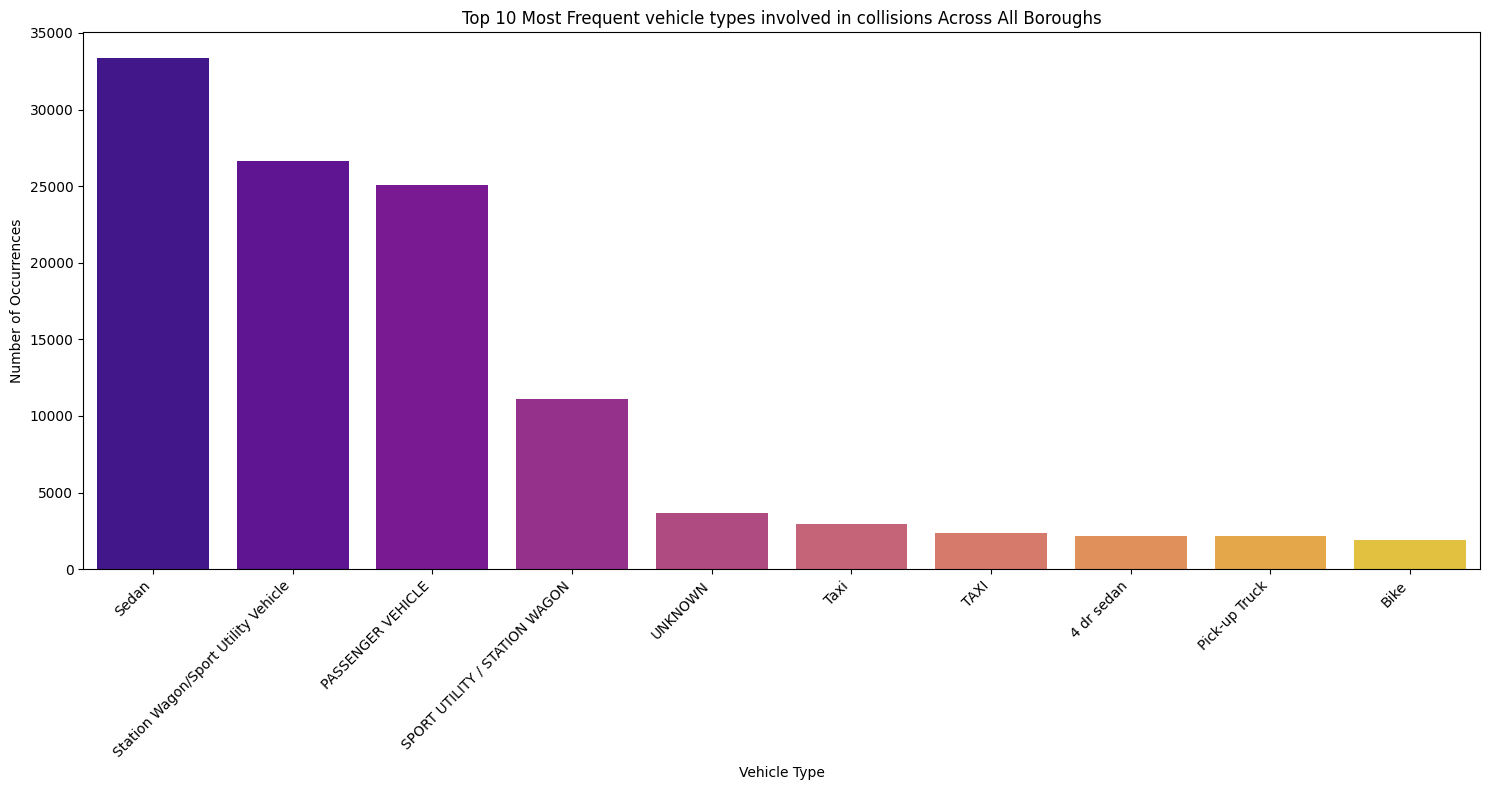

In [17]:
#creating bar graph of to compare vehicle type in collisions
plt.figure(figsize=(15, 8))
sns.barplot(x=vehicle_type_counts_all_boroughs.head(10).index, y=vehicle_type_counts_all_boroughs.head(10).values, palette='plasma')
plt.title('Top 10 Most Frequent vehicle types involved in collisions Across All Boroughs')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The graph shows that across all the boroughs, sedans are involved in majority of collisions.
surprisingly, bikes has the least, eventhough number of accidents involving bikes are quite high recently.

## Analyzing Crash Date Range

In [18]:
# Convert 'CRASH DATE' to datetime objects
df_final['CRASH DATE'] = pd.to_datetime(df_final['CRASH DATE'], errors='coerce')

# Get the minimum and maximum crash dates
min_crash_date = df_final['CRASH DATE'].min()
max_crash_date = df_final['CRASH DATE'].max()

print(f"Minimum Crash Date: {min_crash_date}")
print(f"Maximum Crash Date: {max_crash_date}")

Minimum Crash Date: 2012-07-01 00:00:00
Maximum Crash Date: 2026-05-12 00:00:00


In [19]:
collisions_brooklyn_before_2014 = df_final[
    (df_final['BOROUGH'] == 'BROOKLYN') &
    (df_final['CRASH DATE'].dt.year < 2014)
]

total_collisions_brooklyn_before_2014 = collisions_brooklyn_before_2014['Total Injuries'].sum()

print(f"Total number of collisions in Brooklyn before 2014: {int(total_collisions_brooklyn_before_2014)}")

Total number of collisions in Brooklyn before 2014: 1983


In [20]:
collisions_brooklyn_after_2014 = df_final[
    (df_final['BOROUGH'] == 'BROOKLYN') &
    (df_final['CRASH DATE'].dt.year > 2014)
]

total_collisions_brooklyn_after_2014 = collisions_brooklyn_after_2014['Total Injuries'].sum()

print(f"Total number of collisions in Brooklyn after 2014: {int(total_collisions_brooklyn_after_2014)}")

Total number of collisions in Brooklyn after 2014: 12756


In [21]:
#visualizing impact of vision zero
unique_years_before_2014 = collisions_brooklyn_before_2014['CRASH DATE'].dt.year.nunique()

if unique_years_before_2014 > 0:
    average_collisions_per_year_before_2014 = total_collisions_brooklyn_before_2014 / unique_years_before_2014
    print(f"Average number of collisions per year in Brooklyn before 2014: {average_collisions_per_year_before_2014:.2f}")
else:
    print("No collisions found in Brooklyn before 2014 to calculate an average.")

Average number of collisions per year in Brooklyn before 2014: 991.50


In [22]:
unique_years_after_2014 = collisions_brooklyn_after_2014['CRASH DATE'].dt.year.nunique()

if unique_years_after_2014 > 0:
    average_collisions_per_year_after_2014 = total_collisions_brooklyn_after_2014 / unique_years_after_2014
    print(f"Average number of collisions per year in Brooklyn after 2014: {average_collisions_per_year_after_2014:.2f}")
else:
    print("No collisions found in Brooklyn after 2014 to calculate an average.")

Average number of collisions per year in Brooklyn after 2014: 1063.00


/tmp/ipykernel_1100/2199142435.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Average Collisions Per Year', data=avg_collisions_df, palette='viridis')


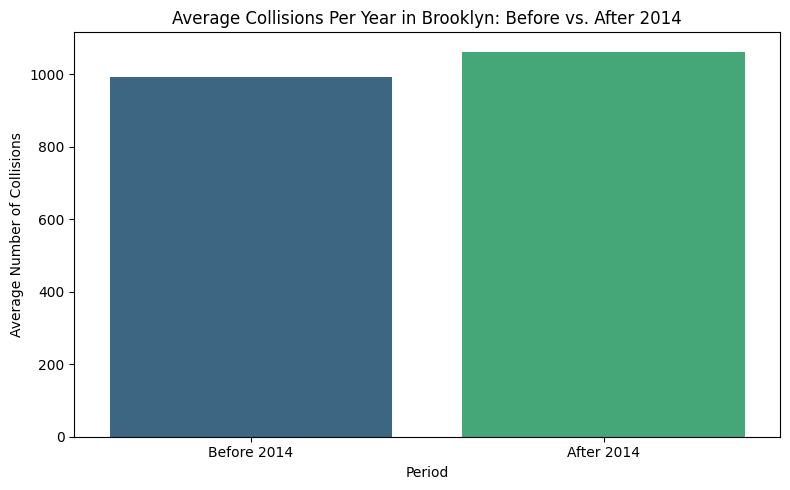

In [25]:
data = {
    'Period': ['Before 2014', 'After 2014'],
    'Average Collisions Per Year': [average_collisions_per_year_before_2014, average_collisions_per_year_after_2014]
}

avg_collisions_df = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
sns.barplot(x='Period', y='Average Collisions Per Year', data=avg_collisions_df, palette='viridis')
plt.title('Average Collisions Per Year in Brooklyn: Before vs. After 2014')
plt.xlabel('Period')
plt.ylabel('Average Number of Collisions')
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()

This result does not allighn with the expected conclusion or what has been reported in various news articles which states a decrease in collisions. I think this is because the original dataset only had two years of data before 2014 and 12 years of data after 2014. So when I randomnly chose 100000 datapoints, the majority of datapoints were for after 2014. This means when the average was taken, most of the collisions occured after 2014. Most news articles states a decrease in traffic fatalities since New York City launched the Vision Zero in 2014.